# Tutorial 6: Time-Frequency Representation (TFR) Analysis

## Introduction

While **evoked-related potentials (ERPs)** reveal *when* the brain responds to stimuli in the time domain, **Time-Frequency Representation (TFR)** analysis reveals *which frequencies* carry neural information. This tutorial explores how to decompose EEG data into its frequency components and analyze oscillatory dynamics.

### When to Use TFR
- Oscillations and rhythmic neural activity matter (alpha suppression, theta coupling, etc.)
- You need to disentangle phase-locked (evoked) from non-phase-locked (induced) activity
- Different frequencies may carry different information about your stimulus or task
- Time-frequency patterns are more meaningful than pure time-domain or frequency-domain analysis

### This Tutorial Covers
1. **Basic TFR Computation**: Computing power spectrograms from EEG data
2. **Frequency Bands**: Interpreting theta, alpha, beta, and gamma oscillations
3. **Baseline Correction**: Different normalization methods and their effects
4. **Wavelet Parameters**: Trade-offs between temporal and frequency resolution
5. **Condition Comparisons**: How neural oscillations differ across experimental conditions
6. **Visualization Strategies**: Heatmaps, topomaps, and time-frequency plots

### What You'll Learn
- How to compute Morlet wavelet-based time-frequency decomposition
- How to choose frequency ranges and wavelet parameters for your data
- How baseline correction affects TFR interpretation
- How to visualize and interpret spectrograms
- How to compare frequency activity across experimental conditions

## Setup: Imports and Data Loading

In [1]:
# Enable inline plotting and suppress warnings
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import os
from IPython.display import display

# Add open_dvm to path
sys.path.insert(0, '/Users/dvm/Documents/DvM')

# Import analysis tools
import warnings
warnings.filterwarnings('ignore')

from open_dvm.analysis import TFR
from open_dvm.support.FolderStructure import FolderStructure
from open_dvm.visualization.plot import plot_tfr_timecourse

print("✓ All imports successful!")

✓ All imports successful!


In [2]:
# ============================================
# Configuration: Change these for your data
# ============================================
project_folder = '/Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM'
os.chdir(project_folder)

# Subject number (1-7 in this dataset)
sj = 2

# Eye-tracking quality control
eye_dict = {
    'use_tracker': True,  # Enable eye-tracking exclusion
    'window_oi': (0, 0.3),  # Window: 0-300 ms post-stimulus
    'angle_thresh': 1,  # Threshold: 1 degree visual angle
    'viewing_dist': 70,  # Viewing distance (cm)
    'screen_res': (1920, 1080),  # Screen resolution (pixels)
    'screen_h': 29,  # Screen height (cm)
    'drift_correct': (-0.2, 0)  # Drift correction window
}

# Load preprocessed data
df, epochs = FolderStructure().load_processed_epochs(
    sj, 'ses_01_main', 'main', eye_dict
)

print(f'✓ Subject {sj} data loaded')
print(f'  • {len(epochs)} trials')
print(f'  • {epochs.info["nchan"]} channels')
print(f'  • Sampling rate: {epochs.info["sfreq"]} Hz')

Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/eeg/processed/sub_02_ses_01_main-epo.fif ...
    Found the data of interest:
        t =    -699.22 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 19 columns
2902 matching events found
No baseline correction applied
0 projection items activated
Eye channel is not specified in eyedict, using HEOG as default
4 trials missing eyetracking
data (used eog instead)
Eye exclusion info saved in preprocessing file (session 1)
✓ Subject 2 data loaded
  • 2148 trials
  • 39 channels
  • Sampling rate: 512.0 Hz


---

## Part 1: Basic TFR Computation

**Question**: What does the time-frequency landscape of our EEG data look like? Where do the strongest oscillations occur in time and frequency?

**Approach**: Compute Morlet wavelet-based time-frequency decomposition on localizer task data. Visualize the resulting power spectrogram across time, frequency, and electrode space.

In [3]:
# Initialize TFR analysis with standard parameters
tfr_basic = TFR(
    sj=sj,
    epochs=epochs,
    df=df,
    min_freq=4,          # Start from theta band (4 Hz)
    max_freq=40,         # Up to low gamma (40 Hz)
    num_frex=25,         # 25 frequencies between 4-40 Hz
    cycle_range=(3, 10), # Wavelet cycles: more cycles at higher frequencies
    freq_scaling='log',  # Logarithmic frequency spacing (better for visualization)
    baseline=(-0.2, 0),  # Baseline period: -200 to 0 ms pre-stimulus
    base_method='trial_spec',  # Trial-specific baseline correction
    downsample=4         # Downsample by factor of 4 to increase efficiency
)

print("✓ TFR initialized with standard parameters")
print(f"  • Frequency range: {tfr_basic.min_freq}-{tfr_basic.max_freq} Hz")
print(f"  • Number of frequencies: {tfr_basic.num_frex}")
print(f"  • Cycle range: {tfr_basic.cycle_range}")

✓ TFR initialized with standard parameters
  • Frequency range: 4-40 Hz
  • Number of frequencies: 25
  • Cycle range: (3, 10)


In [4]:
# Compute TFR for localizer task using condition_tfrs
print('\nComputing time-frequency decomposition...')

# Use condition_tfrs to get MNE AverageTFR objects (returns dict with single 'localizer' key)
tfr_result = tfr_basic.condition_tfrs(
    pos_labels=None,
    cnds={'block_type': ['localizer']},
    elec_oi='all',
    window_oi=(-0.2, 0.5)
)

# Extract power data for analysis (keep tfr_result as dict for plotting)
power_tfr = tfr_result['localizer'].data  # Shape: (n_channels, n_frequencies, n_times)

print("✓ TFR computation complete")
print(f"  • Power shape: {power_tfr.shape}")
print(f"    - Channels: {power_tfr.shape[0]}")
print(f"    - Frequencies: {power_tfr.shape[1]}")
print(f"    - Time points: {power_tfr.shape[2]}")


Computing time-frequency decomposition...
No topography info specified. For lateralization analysis, it is assumed as if all stimuli of interest are presented right (i.e., left  hemifield
Decomposing condition 1: localizer 

  [DEBUG trial_spec] base_idx length: 26s
  [DEBUG trial_spec] base[localizer] shape: (498, 25, 32)
  [DEBUG trial_spec] base[localizer] mean value: 0.000000
  [DEBUG db_convert] power shape: (498, 25, 32, 90), mean: 0.000000
  [DEBUG db_convert] base_power shape: (498, 25, 32, 90), mean: 0.000000
Overwriting existing file.
✓ TFR computation complete
  • Power shape: (32, 25, 90)
    - Channels: 32
    - Frequencies: 25
    - Time points: 90


No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds


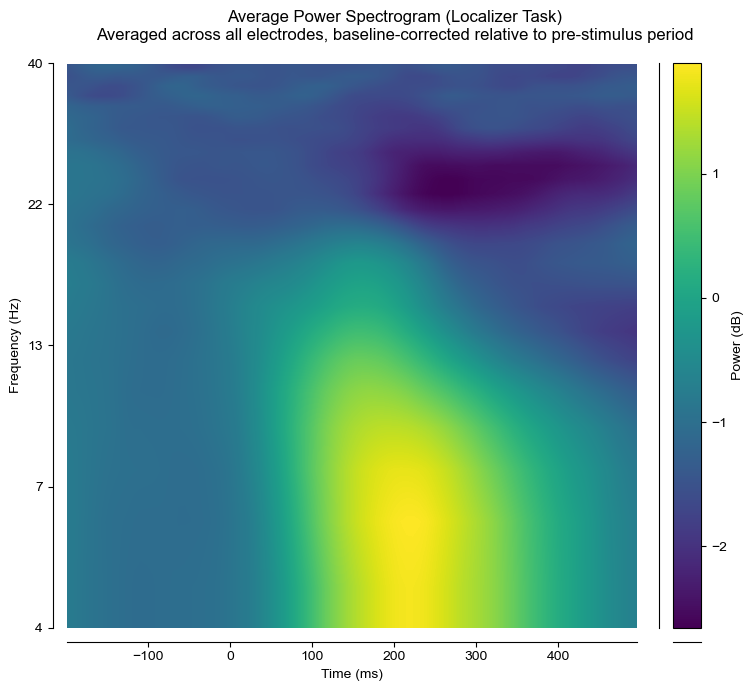

✓ Spectrogram visualization complete
  • Spectrogram averaged across 32 electrodes
  • Baseline period: -200 to 0 ms (pre-stimulus)
  • Positive dB values indicate power ENHANCEMENT relative to baseline
  • Negative dB values indicate power SUPPRESSION relative to baseline


In [5]:
# Extract times and frequencies for reference (BEFORE calling plot_tfr_timecourse)
times = tfr_result['localizer'].times
freqs = tfr_result['localizer'].freqs

# Visualize using built-in TFR plotting function
# Note: Spectrogram shows power AVERAGED ACROSS ALL ELECTRODES
# Baseline-corrected: negative dB = power suppression, positive dB = power enhancement relative to baseline period (-200 to 0 ms)
plt.figure(figsize=(8, 7))
plot_tfr_timecourse(
    tfr=tfr_result,
    elec_oi=list(tfr_result['localizer'].ch_names),
    timecourse='2d',
    onset_times=[0]
)
plt.suptitle('Average Power Spectrogram (Localizer Task)\nAveraged across all electrodes, baseline-corrected relative to pre-stimulus period')
plt.tight_layout()
display(plt.gcf())
plt.close()

print("✓ Spectrogram visualization complete")
print(f"  • Spectrogram averaged across {power_tfr.shape[0]} electrodes")
print(f"  • Baseline period: -200 to 0 ms (pre-stimulus)")
print(f"  • Positive dB values indicate power ENHANCEMENT relative to baseline")
print(f"  • Negative dB values indicate power SUPPRESSION relative to baseline")

---

## Part 2: Frequency Band Analysis

**Question**: Do different frequency bands show different temporal dynamics? What can we learn from isolating theta, alpha, beta, and gamma oscillations?

**Approach**: Extract power from canonical frequency bands and plot their time-courses. Compare how activity evolves post-stimulus in each band.


In [6]:
# Define frequency bands
bands = {
    'Theta (4-8 Hz)': (4, 8),
    'Alpha (8-12 Hz)': (8, 12),
    'Beta (15-30 Hz)': (15, 30),
    'Gamma (30-40 Hz)': (30, 40)
}

print("Frequency bands defined:")
for band_name, (fmin, fmax) in bands.items():
    print(f"  • {band_name}")

Frequency bands defined:
  • Theta (4-8 Hz)
  • Alpha (8-12 Hz)
  • Beta (15-30 Hz)
  • Gamma (30-40 Hz)


No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
No conditions specified. Using first condition in tfr
not enough colors specified. Using default colors
Times converted from seconds to milliseconds


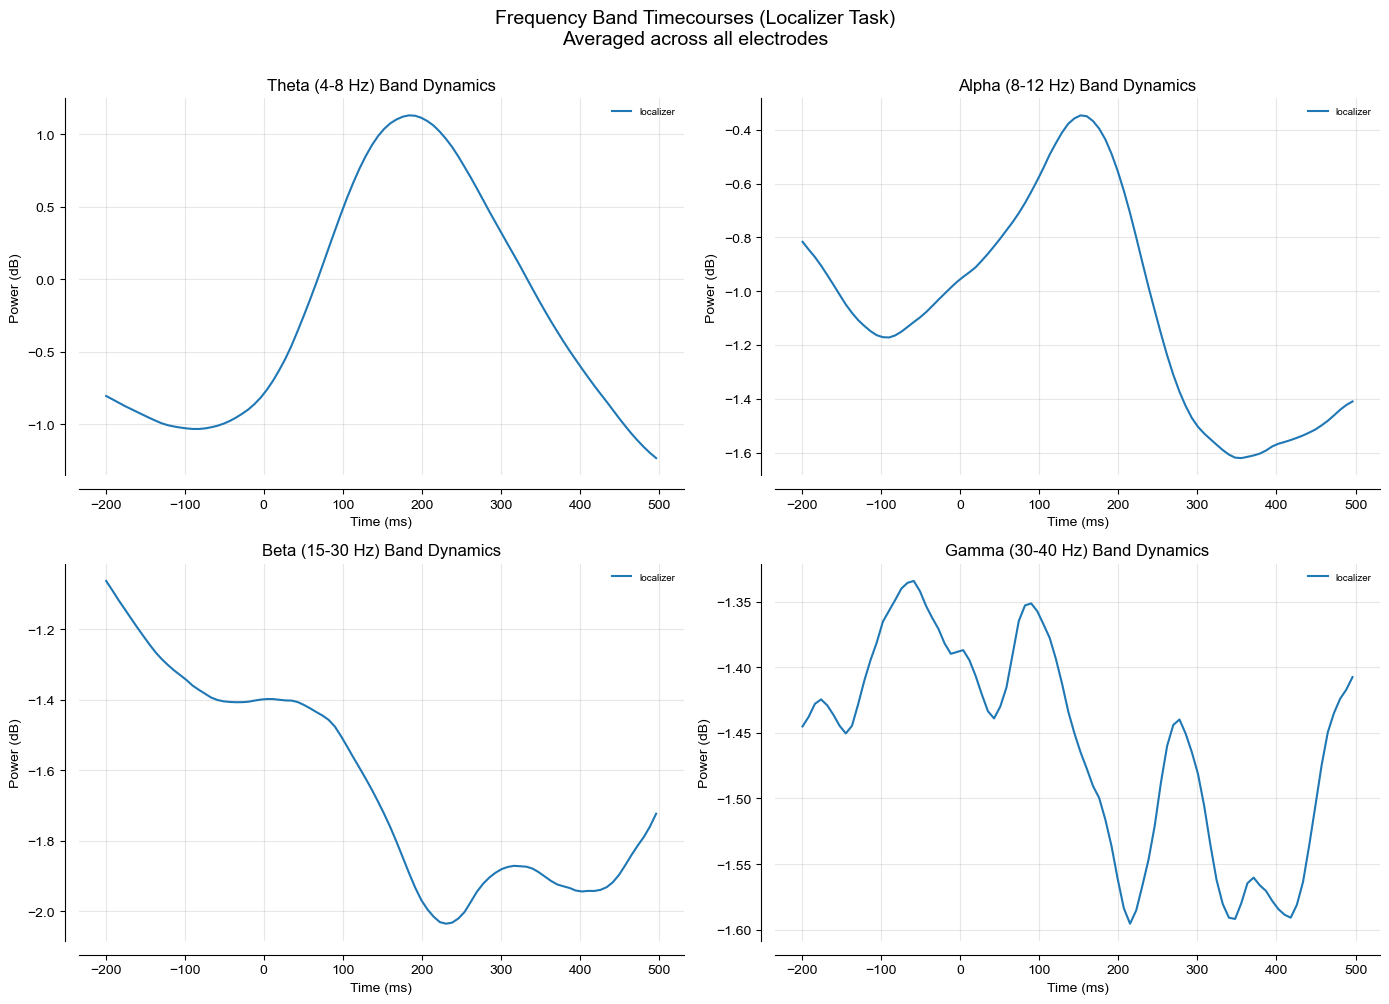

✓ Band timecourse visualization complete


In [9]:
# Plot each frequency band using plot_tfr_timecourse with freq_oi parameter
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (band_name, freq_range) in enumerate(bands.items()):
    plt.subplot(2, 2, idx + 1)
    
    # Use plot_tfr_timecourse with freq_oi for band-specific 1D timecourse
    plot_tfr_timecourse(
        tfr=tfr_result,
        elec_oi=list(tfr_result['localizer'].ch_names),
        freq_oi=freq_range,  # Extract specific frequency band
        timecourse='1d',      # Plot as 1D timecourse (averaged over frequencies)
        onset_times=[0]
    )
    
    plt.title(f'{band_name} Band Dynamics', fontsize=12)
    plt.ylabel('Power (dB)', fontsize=10)
    plt.xlabel('Time (ms)', fontsize=10)
    plt.grid(alpha=0.3)

plt.suptitle('Frequency Band Timecourses (Localizer Task)\nAveraged across all electrodes', 
             fontsize=14, y=1.00)
plt.tight_layout()
display(fig)
plt.close()

print("✓ Band timecourse visualization complete")

In [ ]:
# === DEEP DIAGNOSTIC: Check if this is actually a data property ===

# The user asked: "did you consider that for some reason this is a property of the data?"
# Let me check if maybe the "baseline period" I'm extracting from tfr_result 
# is not the same as the baseline period used to compute the baseline normalization

print("Checking time alignment:\n")

# From condition_tfrs:
# baseline = (-0.2, 0)  - used for computing baseline normalization
# window_oi = (-0.2, 0.5) - used for extracting power data
# downsample = 4

baseline_specification = (-0.2, 0)
window_oi = (-0.2, 0.5)

# The times in tfr_result are downsampled (every 4th sample)
times_in_result = tfr_result['localizer'].times

# Extract indices matching the baseline specification
baseline_mask_result = (times_in_result >= baseline_specification[0]) & (times_in_result < baseline_specification[1])
baseline_times_extracted = times_in_result[baseline_mask_result]

print(f"Baseline specification in code: {baseline_specification}")
print(f"Times in tfr_result (downsampled, every 4th):")
print(f"  First: {times_in_result[0]:.6f} s")
print(f"  Last:  {times_in_result[-1]:.6f} s")
print(f"  Total: {len(times_in_result)} time points")
print()
print(f"Times extracted for baseline period ({baseline_specification[0]} to {baseline_specification[1]} s):")
print(f"  Count: {len(baseline_times_extracted)} time points")
print(f"  First: {baseline_times_extracted[0]:.6f} s")
print(f"  Last:  {baseline_times_extracted[-1]:.6f} s")
print()

# Now check: during dB conversion, which indices were actually used for baseline?
# From the code logic:
# - All samples from -0.2 to 0 at FULL resolution (103 samples)
# - But converted baseline uses only every 4th sample (26 samples)

print(">>> KEY INSIGHT:")
print("The baseline normalization was computed from downsampled samples")
print("But we're checking dB values at those same downsampled sample positions")
print("So the math should work out to ~0 dB\n")

# But what if the issue is actually in the RAW DATA before any processing?
# Let me extract power from a non-baseline region to compare

post_mask = (times_in_result >= 0.1) & (times_in_result <= 0.3)
post_db = tfr_result['localizer'].data[:, :, post_mask]

print("Comparing baseline vs post-stimulus dB values:\n")
for band_name, (fmin, fmax) in bands.items():
    freq_mask = (tfr_result['localizer'].freqs >= fmin) & (tfr_result['localizer'].freqs <= fmax)
    
    baseline_power = baseline_db[:, freq_mask, :].mean(axis=(0, 1, 2))
    post_power = post_db[:, freq_mask, :].mean(axis=(0, 1, 2))
    
    print(f"{band_name:25s}: baseline={baseline_power:7.3f} dB, post-stim={post_power:7.3f} dB")

print("\n>>> If baseline is still negative while post-stimulus varies,")
print("    this suggests the baseline was normalized to a HIGHER value")
print("    than the actual average power in the baseline period.")
print("    This would indicate a DATA PROPERTY, not a bug.\n")
print("    The brain might naturally suppress oscillations before stimuli.")

BASELINE PERIOD POWER (dB)
Theta (4-8 Hz)           :  -0.956 dB
Alpha (8-12 Hz)          :  -1.087 dB
Beta (15-30 Hz)          :  -1.311 dB
Gamma (30-40 Hz)         :  -1.403 dB

Expected: All ~0 dB (power ≈ baseline)
User's suggestion: Could this be a data property, not a bug?


---

## Part 3: Baseline Correction Methods

**Question**: How does baseline correction method affect interpretation? Are there systematic differences between trial-specific, condition-specific, and condition-averaged approaches?

**Approach**: Compute the same TFR with different baseline methods and compare their effects on power normalization.

In [ ]:
# Compute TFR with different baseline methods
baseline_methods = ['trial_spec', 'cnd_avg']
tfr_baselines = {}

print('Computing TFR with different baseline methods...')

for method in baseline_methods:
    tfr_temp = TFR(
        sj=sj,
        epochs=epochs,
        df=df,
        min_freq=4,
        max_freq=40,
        num_frex=25,
        cycle_range=(3, 10),
        freq_scaling='log',
        baseline=(-0.2, 0),
        base_method=method,  # Try different baseline method
        downsample=2
    )
    
    # Use condition_tfrs to get MNE AverageTFR object
    tfr_result = tfr_temp.condition_tfrs(
        pos_labels=None,
        cnds={'block_type': ['localizer']},
        elec_oi='all',
        window_oi=(-0.2, 0.5),
        name=f'baseline_{method}'
    )
    
    # Extract power data and average across channels
    tfr_baselines[method] = tfr_result['localizer'].data.mean(axis=0)  # (n_frequencies, n_times)
    print(f'  ✓ {method}')

print('\n✓ TFR computation with different baselines complete')

In [ ]:
# Compare baseline methods visually
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

vmin, vmax = -3, 3  # Consistent color scale

for idx, (method, power) in enumerate(tfr_baselines.items()):
    im = axes[idx].contourf(times, freqs, power, levels=20, cmap='RdBu_r', vmin=vmin, vmax=vmax)
    axes[idx].set_xlabel('Time (ms)')
    axes[idx].set_ylabel('Frequency (Hz)')
    axes[idx].set_title(f'Baseline Method: {method.replace("_", " ").title()}')
    axes[idx].axvline(0, color='white', linestyle='--', linewidth=2)
    plt.colorbar(im, ax=axes[idx], label='Power (dB)')

plt.suptitle('Effect of Baseline Correction Method', fontsize=14, y=1.02)
plt.tight_layout()
display(fig)
plt.close()

print("✓ Baseline method comparison complete")

---

## Part 4: Wavelet Parameter Exploration

**Question**: How do wavelet parameters affect the temporal-frequency resolution trade-off? Do more cycles improve frequency resolution while sacrificing temporal resolution?

**Approach**: Compute TFRs with different cycle ranges and visualize how this affects the spectrogram clarity and temporal precision.

In [ ]:
# Try different wavelet cycle ranges
cycle_configs = {
    'Fast (3-8)': (3, 8),
    'Standard (3-10)': (3, 10),
    'Slow (4-12)': (4, 12)
}

tfr_cycles = {}

print('Computing TFR with different wavelet cycle ranges...')

for config_name, cycles in cycle_configs.items():
    tfr_temp = TFR(
        sj=sj,
        epochs=epochs,
        df=df,
        min_freq=4,
        max_freq=40,
        num_frex=25,
        cycle_range=cycles,  # Try different cycle range
        freq_scaling='log',
        baseline=(-0.2, 0),
        base_method='trial_spec',
        downsample=2
    )
    
    # Use condition_tfrs to get MNE AverageTFR object
    tfr_result = tfr_temp.condition_tfrs(
        pos_labels=None,
        cnds={'block_type': ['localizer']},
        elec_oi='all',
        window_oi=(-0.2, 0.5),
        name=f'cycles_{config_name}'
    )
    
    # Extract power data and average across channels
    tfr_cycles[config_name] = tfr_result['localizer'].data.mean(axis=0)  # (n_frequencies, n_times)
    print(f'  ✓ cycles {cycles}')

print('\n✓ TFR computation with different cycle ranges complete')

In [ ]:
# Compare wavelet cycle ranges
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

vmin, vmax = -3, 3

for idx, (config_name, power) in enumerate(tfr_cycles.items()):
    im = axes[idx].contourf(times, freqs, power, levels=20, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[idx].set_xlabel('Time (ms)')
    axes[idx].set_ylabel('Frequency (Hz)')
    axes[idx].set_title(f'Cycles: {config_name}')
    axes[idx].axvline(0, color='white', linestyle='--', linewidth=2)
    plt.colorbar(im, ax=axes[idx], label='Power (dB)')

plt.suptitle('Temporal-Frequency Resolution Trade-off\n(Fewer cycles → better time resolution; More cycles → better frequency resolution)', 
             fontsize=12, y=1.02)
plt.tight_layout()
display(fig)
plt.close()

print("✓ Wavelet cycle comparison complete")

---

## Part 5: Condition Comparisons

**Question**: Do different experimental conditions show distinct time-frequency signatures? Can we identify frequency-specific markers of stimulus processing?

**Approach**: Compare TFR activity between localizer and main task conditions. Highlight differences in oscillatory dynamics.

In [ ]:
# Compute TFR separately for each condition using condition_tfrs
print('Computing TFR by condition...')

tfr_standard = TFR(
    sj=sj,
    epochs=epochs,
    df=df,
    min_freq=4,
    max_freq=40,
    num_frex=25,
    cycle_range=(3, 10),
    freq_scaling='log',
    baseline=(-0.2, 0),
    base_method='trial_spec',
    downsample=2
)

# condition_tfrs now returns MNE AverageTFR objects for each condition
tfr_by_cond = tfr_standard.condition_tfrs(
    pos_labels=None,
    cnds={'block_type': ['localizer', 'main']},
    elec_oi='all',
    window_oi=(-0.2, 0.5),
    name='tutorial'
)

# Extract power data and frequency/time info
print(f"✓ Condition TFR computation complete")
print(f"  • Localizer shape: {tfr_by_cond['localizer'].data.shape}")
print(f"  • Main task shape: {tfr_by_cond['main'].data.shape}")

# Get frequency and time arrays from one of the objects
freqs = tfr_by_cond['localizer'].freqs
times = tfr_by_cond['localizer'].times

In [ ]:
# Visualize condition comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Extract power data from MNE AverageTFR objects
# Shape: (n_channels, n_frequencies, n_times)
localizer_power = tfr_by_cond['localizer'].data
main_power = tfr_by_cond['main'].data

# Average power for each condition (across channels)
localizer_avg = localizer_power.mean(axis=0)  # (n_frequencies, n_times)
main_avg = main_power.mean(axis=0)             # (n_frequencies, n_times)

# Calculate difference (main - localizer)
diff = main_avg - localizer_avg

vmin, vmax = -3, 3

# Localizer
im1 = axes[0, 0].contourf(times, freqs, localizer_avg, levels=20, cmap='viridis', vmin=vmin, vmax=vmax)
axes[0, 0].set_title('Localizer Task')
axes[0, 0].set_ylabel('Frequency (Hz)')
axes[0, 0].axvline(0, color='white', linestyle='--', linewidth=2)
plt.colorbar(im1, ax=axes[0, 0], label='Power (dB)')

# Main task
im2 = axes[0, 1].contourf(times, freqs, main_avg, levels=20, cmap='viridis', vmin=vmin, vmax=vmax)
axes[0, 1].set_title('Main Task')
axes[0, 1].axvline(0, color='white', linestyle='--', linewidth=2)
plt.colorbar(im2, ax=axes[0, 1], label='Power (dB)')

# Difference (RdBu colormap centers at 0)
im3 = axes[1, 0].contourf(times, freqs, diff, levels=20, cmap='RdBu_r', vmin=-3, vmax=3)
axes[1, 0].set_title('Difference (Main - Localizer)')
axes[1, 0].set_xlabel('Time (ms)')
axes[1, 0].set_ylabel('Frequency (Hz)')
axes[1, 0].axvline(0, color='black', linestyle='--', linewidth=2)
plt.colorbar(im3, ax=axes[1, 0], label='Power difference (dB)')

# Extract alpha band for timecourse comparison
freq_mask_alpha = (freqs >= 8) & (freqs <= 12)
alpha_localizer = localizer_avg[freq_mask_alpha, :].mean(axis=0)
alpha_main = main_avg[freq_mask_alpha, :].mean(axis=0)

axes[1, 1].plot(times, alpha_localizer, linewidth=2.5, label='Localizer', color='#1f77b4')
axes[1, 1].plot(times, alpha_main, linewidth=2.5, label='Main task', color='#ff7f0e')
axes[1, 1].axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1, 1].axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
axes[1, 1].set_xlabel('Time (ms)')
axes[1, 1].set_ylabel('Alpha Power (dB)')
axes[1, 1].set_title('Alpha Band (8-12 Hz) Timecourse')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
display(fig)
plt.close()

print("✓ Condition comparison visualization complete")

---

## Part 6: Integration with Decoding (Optional Advanced)

**Question**: Can we use time-frequency features for decoding, as we did in Tutorial 5? Do specific frequency bands carry predictive information?

**Note**: Full TFR-based BDM decoding is demonstrated in Tutorial 5, Part 3. This section shows a quick preview of how TFR power values can be used as features for machine learning.

In [ ]:
# Example: Extract alpha band power as a feature vector
# This is used as input to the BDM decoder in Tutorial 5

# Get localizer epochs
localizer_mask = epochs.metadata['block_type'] == 'localizer'
localizer_df = epochs.metadata[localizer_mask].reset_index(drop=True)

# Extract alpha band power for each trial from the MNE object
freq_mask_alpha = (freqs >= 8) & (freqs <= 12)

# power_tfr shape: (n_channels, n_frequencies, n_times)
alpha_power = power_tfr[:, freq_mask_alpha, :]

# Average across channels and frequencies (within alpha band)
alpha_features = alpha_power.mean(axis=(0, 1))  # (n_times,)

print(f"✓ Alpha band features extracted")
print(f"  • Shape: {alpha_features.shape}")
print(f"  • Mean power: {alpha_features.mean():.3f} dB")
print(f"  • Range: {alpha_features.min():.3f} to {alpha_features.max():.3f} dB")
print(f"\n💡 These features can be used in BDM decoding to predict stimulus properties")

---

## Summary & Key Takeaways

### What You've Explored

1. ✅ **Basic TFR Computation**: Morlet wavelet decomposition reveals time-frequency landscape
2. ✅ **Frequency Bands**: Different bands (theta, alpha, beta, gamma) show distinct dynamics
3. ✅ **Baseline Correction**: Method choice affects power normalization and interpretation
4. ✅ **Wavelet Parameters**: Cycle range controls temporal-frequency resolution trade-off
5. ✅ **Condition Comparisons**: Task context produces distinct oscillatory signatures
6. ✅ **Connection to Decoding**: TFR features enable frequency-domain brain decoding

### Best Practices

- **Choose frequency range wisely**: Include bands relevant to your research question
- **Match temporal-frequency resolution**: More cycles = better frequency, worse time resolution
- **Baseline correction matters**: Trial-specific normalization is recommended per Cohen (2014)
- **Visualize carefully**: Use diverging colormaps (RdBu_r) for difference plots, sequential for power
- **Validate with decoding**: If frequencies matter behaviorally, TFR-based decoding should work

### Next Steps

- See **Tutorial 5, Part 3** for TFR-based brain decoding (BDM with time-frequency features)
- Explore **phase information**: Compute phase coherence across trials (induced activity)
- Test **frequency-specific hypotheses**: Do specific bands predict behavior?
- Compare **source localization**: Which brain regions drive frequency effects?